"o arquivo usava ";" entre colunas e "," nos valores decimais" 
aparecia mensagem de erro parsererror por causa disso

solucao usar SEP

In [24]:
import pandas as pd
import numpy as np

Real_State = pd.read_csv("Real estate valuation data set.csv", sep=";", decimal=",")
Real_State.shape


(414, 8)

arquivo com 414 linhas e 8 colunas

In [25]:
Real_State.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


"Informações Adicionais sobre Variáveis
As entradas são as seguintes
X1=a data da transação (por exemplo, 2013.250=março de 2013, 2013.500=junho de 2013, etc.)
X2=a idade da casa (unidade: ano)
X3=a distância até a estação de MRT mais próxima (unidade: medidor)
X4=o número de lojas de conveniência no círculo de vida a pé (inteiro)
X5=a coordenada geográfica, latitude. (unidade: grau)
X6=a coordenada geográfica, longitude. (unidade: grau)

A saída é a seguinte
Y = preço da casa por área unitária (10.000 Novo Dólar de Taiwan/Ping, onde Ping é uma unidade local, 1 Ping = 3,3 metros quadrados) "


como X1 nao esta em um formato correto tenho que realizar a transformação dos dados 
coverter, a ideia é:

2013 = ano
0.250 = 3 meses do ano
0.500 = 6 meses do ano
0.750 = 9 meses do ano

In [27]:
# Corrige o nome da coluna e converte X1 para mês-ano
Real_State = Real_State.rename(columns={"X1 transaction date": "X1"})

Real_State["X1"] = pd.to_numeric(Real_State["X1"], errors="coerce")
Real_State["ano"] = Real_State["X1"].astype(int)
Real_State["fracao_ano"] = Real_State["X1"] - Real_State["ano"]
Real_State["mes"] = (Real_State["fracao_ano"] * 12).round().astype(int)
Real_State["mes"] = Real_State["mes"].clip(lower=1, upper=12)
Real_State["mes_ano"] = Real_State["mes"].apply(lambda m: f"{m:02d}") + "-" + Real_State["ano"].astype(str)

Real_State[["X1", "mes_ano"]].head()

Real_State.head()

,No,X1,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,ano,fracao_ano,mes,mes_ano
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9,2012,0.917,11,11-2012
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2,2012,0.917,11,11-2012
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3,2013,0.583,7,07-2013
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8,2013,0.500,6,06-2013
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1,2012,0.833,10,10-2012


In [28]:
Real_State.head(50)


,No,X1,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,ano,fracao_ano,mes,mes_ano
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9,2012,0.917,11,11-2012
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2,2012,0.917,11,11-2012
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3,2013,0.583,7,07-2013
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8,2013,0.500,6,06-2013
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1,2012,0.833,10,10-2012
5,6,2012.667,7.1,2175.03000,3,24.96305,121.51254,32.1,2012,0.667,8,08-2012
6,7,2012.667,34.5,623.47310,7,24.97933,121.53642,40.3,2012,0.667,8,08-2012
7,8,2013.417,20.3,287.60250,6,24.98042,121.54228,46.7,2013,0.417,5,05-2013
8,9,2013.500,31.7,5512.03800,1,24.95095,121.48458,18.8,2013,0.500,6,06-2013
9,10,2013.417,17.9,1783.18000,3,24.96731,121.51486,22.1,2013,0.417,5,05-2013


In [31]:
Real_State["preco_por_m2"] = (
    Real_State["Y house price of unit area"] * 10000 / 3.3
)


preco por metro quadrado

In [32]:
Real_State.head(50)

,No,X1,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,ano,fracao_ano,mes,mes_ano,preco_por_m2
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9,2012,0.917,11,11-2012,114848.484848
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2,2012,0.917,11,11-2012,127878.787879
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3,2013,0.583,7,07-2013,143333.333333
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8,2013,0.500,6,06-2013,166060.606061
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1,2012,0.833,10,10-2012,130606.060606
5,6,2012.667,7.1,2175.03000,3,24.96305,121.51254,32.1,2012,0.667,8,08-2012,97272.727273
6,7,2012.667,34.5,623.47310,7,24.97933,121.53642,40.3,2012,0.667,8,08-2012,122121.212121
7,8,2013.417,20.3,287.60250,6,24.98042,121.54228,46.7,2013,0.417,5,05-2013,141515.151515
8,9,2013.500,31.7,5512.03800,1,24.95095,121.48458,18.8,2013,0.500,6,06-2013,56969.696970
9,10,2013.417,17.9,1783.18000,3,24.96731,121.51486,22.1,2013,0.417,5,05-2013,66969.696970


histograma da coluna de preço por metro quadrado

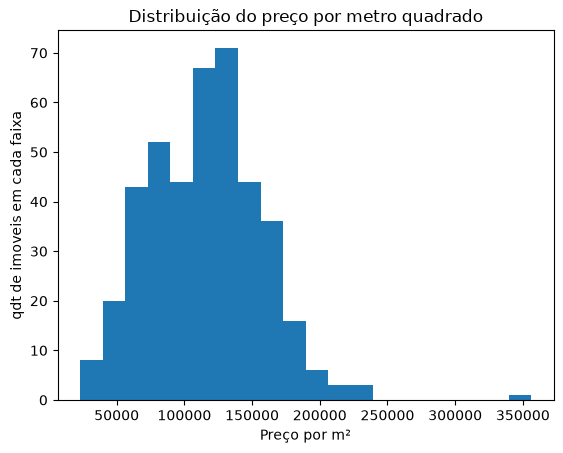

In [34]:
import matplotlib.pyplot as plt

Real_State["preco_por_m2"].plot(kind="hist", bins=20)
plt.xlabel("Preço por m²")
plt.ylabel("qdt de imoveis em cada faixa")
plt.title("Distribuição do preço por metro quadrado")
plt.show()

Com o histograma acima, podemos perceber que os precos se concentram em determinadas faixas.

A média é a idade média das casas negociadas naquele ano; a mediana é o valor central das idades

In [40]:
Real_State.groupby("ano")["X2 house age"].agg(media="mean", mediana="median")

,media,mediana
ano,,
2012,16.866667,15.45
2013,18.082639,16.40


Esses números representam a idade das casas negociadas, em anos, separada pelo ano da transação:

2012: idade média de 16,87 anos; metade das casas tinha até 15,45 anos e metade tinha mais.
2013: idade média de 18,08 anos; metade tinha até 16,40 anos e metade tinha mais.
A média ficou acima da mediana nos dois anos. Isso sugere que algumas casas mais antigas podem estar elevando a média, embora não dê para confirmar a distribuição só com essas medidas.

No conjunto analisado, os imóveis negociados em 2013 eram um pouco mais velhos que os negociados em 2012. Isso compara os imóveis vendidos em cada ano.


In [41]:
Real_State.describe()

,No,X1,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,ano,fracao_ano,mes,preco_por_m2
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193,2012.695652,0.453319,5.507246,115091.494657
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488,0.460687,0.281836,3.280096,41231.780902
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000,2012.000000,0.000000,1.000000,23030.303030
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000,2012.000000,0.250000,3.000000,83939.393939
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000,2013.000000,0.417000,5.000000,116515.151515
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000,2013.000000,0.667000,8.000000,141212.121212
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000,2013.000000,0.917000,11.000000,356060.606061


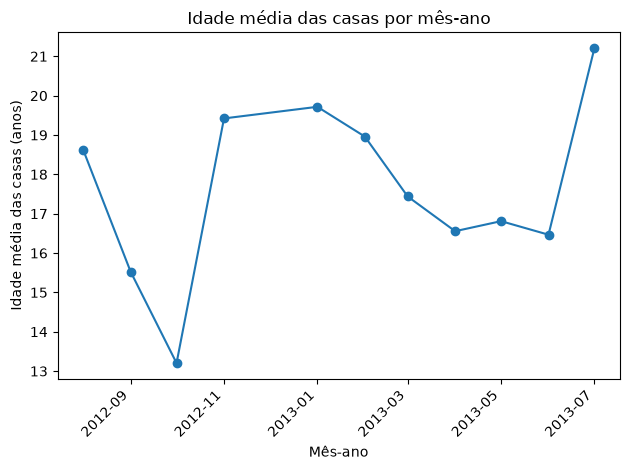

In [35]:
# Idade média das casas por mês/ano
idade_media_mes = Real_State.groupby("mes_ano")["X2 house age"].mean()
idade_media_mes.index = pd.to_datetime(idade_media_mes.index, format="%m-%Y")
idade_media_mes = idade_media_mes.sort_index()

idade_media_mes.plot(kind="line", marker="o")
plt.xlabel("Mês-ano")
plt.ylabel("Idade média das casas (anos)")
plt.title("Idade média das casas por mês-ano")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
# Média e mediana da idade dos imóveis por ano
Real_State.groupby("ano")["X2 house age"].agg(
    media="mean",
    mediana="median"
).round(2)

,media,mediana
ano,,
2012,16.87,15.45
2013,18.08,16.40


Por que em 2013 foram vendidas mais casas (demonstrados nos comandos abaixo)

A planilha registra 288 transações em 2013 e 126 em 2012, mas os períodos observados não têm a mesma duração:

2012: de agosto a novembro, 4 meses, com média de 31,5 registros por mês.
2013: de janeiro a agosto, 8 meses, com média de 36 registros por mês.
Então, a principal explicação visível na planilha é que 2013 tem o dobro de meses representados. Além disso, a média mensal de registros também foi um pouco maior em 2013. Isso explica a diferença dentro desta amostra, mas não prova por que o mercado imobiliário teve mais vendas; a planilha não traz informações sobre causas do mercado.

In [42]:
Real_State.groupby("ano").size()

ano
2012    126
2013    288
dtype: int64

In [43]:
Real_State.groupby(["ano", "mes"]).size()

ano   mes
2012  8      30
      9      27
      10     31
      11     38
2013  1      74
      2      25
      3      32
      4      29
      5      58
      6      47
      7      23
dtype: int64

Considerando as conveniencias e valor do metro quadrado

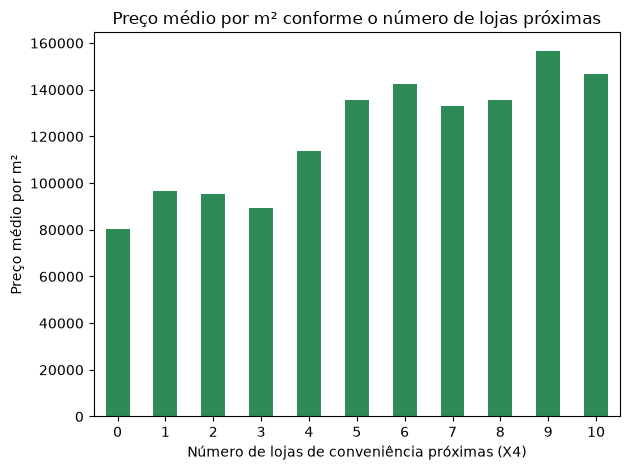

In [45]:
preco_medio_por_lojas = Real_State.groupby("X4 number of convenience stores")["preco_por_m2"].mean()
preco_medio_por_lojas.plot(kind="bar", color="seagreen")
plt.xlabel("Número de lojas de conveniência próximas (X4)")
plt.ylabel("Preço médio por m²")
plt.title("Preço médio por m² conforme o número de lojas próximas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Os dados mostram uma tendência geral positiva: a correlação entre X4 e preço por m² é 0,571, embora existam oscilações entre algumas quantidades de lojas. Portanto, o gráfico sugere uma associação, mas não prova que as lojas causem preços maiores.